# [1] Preparation

In [2]:
# Import libraries
import pandas as pd
import numpy as np

## [1.1] Dataset List

In [3]:
# Show the dataset table
import os

path = "../../data/clean"

for file in os.listdir(path):
    if file.endswith(".csv"):
        print(file)


residential_users_by_acpr.csv
service_users_by_sa3.csv
home_care_users_by_acpr.csv
abs_population_by_sa3.csv
service_funding_by_facility.csv
residential_admissions_by_acpr.csv
homecare_admissions_by_acpr.csv
service_supply_by_sa3.csv
star_ratings_by_facility.csv
master_sa3.csv


In [4]:
df_residential_users_by_acpr = pd.read_csv(path + "/residential_users_by_acpr.csv")
df_service_users_by_sa3 = pd.read_csv(path + "/service_users_by_sa3.csv")
df_home_care_users_by_acpr = pd.read_csv(path + "/home_care_users_by_acpr.csv")
df_abs_population_by_sa3 = pd.read_csv(path + "/abs_population_by_sa3.csv")
df_service_funding_by_facility = pd.read_csv(path + "/service_funding_by_facility.csv")
df_residential_admissions_by_acpr = pd.read_csv(path + "/residential_admissions_by_acpr.csv")
df_homecare_admissions_by_acpr = pd.read_csv(path + "/homecare_admissions_by_acpr.csv")
df_service_supply_by_sa3 = pd.read_csv(path + "/service_supply_by_sa3.csv")
df_star_ratings_by_facility = pd.read_csv(path + "/star_ratings_by_facility.csv")
df_master_sa3 = pd.read_csv(path + "/master_sa3.csv")

### [1.1.1] residential_users_by_acpr
Active residential care users per ACPR region, by care type and demographics.

In [5]:
df_residential_users_by_acpr.head()

,acpr_code,acpr_name,state,year,total_users,n_permanent,n_respite,n_indigenous,n_male,n_female,...,n_age_55_59,n_age_60_64,n_age_65_69,n_age_70_74,n_age_75_79,n_age_80_84,n_age_85_89,n_age_90_94,n_age_95_99,n_age_100_plus
0,101.0,Central Coast,NSW,2024,3477,3304,173,50,1215,2262,...,0,0,0,0,0,0,0,0,0,0
1,102.0,Central West,NSW,2024,1770,1701,69,54,646,1124,...,0,0,0,0,0,0,0,0,0,0
2,103.0,Far North Coast,NSW,2024,3212,3098,114,36,1153,2058,...,0,0,0,0,0,0,0,0,0,0
3,104.0,Hunter,NSW,2024,5985,5808,177,84,1994,3990,...,0,0,0,0,0,0,0,0,0,0
4,105.0,Illawarra,NSW,2024,3775,3675,100,49,1285,2490,...,0,0,0,0,0,0,0,0,0,0


| Column | Meaning |
|--------|---------|
| `acpr_code` | Aged Care Planning Region code |
| `acpr_name` | Region name |
| `state` | Australian state |
| `year` | Reference year |
| `total_users` | Total residential care users |
| `n_permanent` | Permanent care users |
| `n_respite` | Short-term (respite) care users |
| `n_indigenous` | Indigenous users |
| `n_male` / `n_female` | Count by sex |
| `n_nesb` | Non-English speaking background |
| `n_english_speaking` | English-speaking background |
| `n_age_*` | User counts by 5-year age band |

### [1.1.2] service_users_by_sa3
Residential and home care users aggregated at SA3 level.

In [6]:
df_service_users_by_sa3.head()

,sa3_code,sa3_name,year,permanent,respite,total_residential,hcp_level1,hcp_level2,hcp_level3,hcp_level4,total_homecare,total_users,hcp_high_needs,pct_hcp_high
0,10102.0,Queanbeyan,2024,254.0,8.0,262.0,14,252,157,74,497,759.0,231,0.464789
1,10102.0,Queanbeyan,2025,267.0,4.0,271.0,13,228,170,87,498,769.0,257,0.516064
2,10103.0,Snowy Mountains,2024,77.0,0.0,77.0,6,71,43,36,156,233.0,79,0.506410
3,10103.0,Snowy Mountains,2025,73.0,1.0,74.0,2,74,73,38,187,261.0,111,0.593583
4,10104.0,South Coast,2024,871.0,38.0,909.0,74,1016,527,209,1826,2735.0,736,0.403067


| Column | Meaning |
|--------|---------|
| `sa3_code` / `sa3_name` / `year` | SA3 region identifiers |
| `permanent` | Permanent residential care users |
| `respite` | Respite (short-term) residential care users |
| `total_residential` | Total residential users |
| `hcp_level1`–`hcp_level4` | Home Care Package users by level (1=low, 4=high needs) |
| `total_homecare` | Total home care users |
| `total_users` | Combined residential + home care users |
| `hcp_high_needs` | HCP level 3+4 users |
| `pct_hcp_high` | % of home care users on high-needs packages |

### [1.1.3] home_care_users_by_acpr
Active home care users per ACPR region, by demographics and HCP package level.

In [7]:
df_home_care_users_by_acpr.head()

,acpr_code,acpr_name,state,year,total_users,n_indigenous,n_male,n_female,n_nesb,n_english_speaking,...,n_age_75_79,n_age_80_84,n_age_85_89,n_age_90_94,n_age_95_99,n_age_100_plus,hcp_l1,hcp_l2,hcp_l3,hcp_l4
0,101.0,Central Coast,NSW,2024,5142,221,1695,3446,527,558,...,0,0,0,0,0,0,0,0,0,0
1,102.0,Central West,NSW,2024,5572,841,1810,3762,633,294,...,0,0,0,0,0,0,0,0,0,0
2,103.0,Far North Coast,NSW,2024,3578,129,1225,2353,211,377,...,0,0,0,0,0,0,0,0,0,0
3,104.0,Hunter,NSW,2024,6360,316,2058,4302,537,475,...,0,0,0,0,0,0,0,0,0,0
4,105.0,Illawarra,NSW,2024,4080,194,1315,2764,943,426,...,0,0,0,0,0,0,0,0,0,0


| Column | Meaning |
|--------|---------|
| `acpr_code` / `acpr_name` / `state` / `year` | Region identifiers |
| `total_users` | Total home care users |
| `n_male` / `n_female` | Count by sex |
| `n_indigenous` | Indigenous users |
| `n_nesb` / `n_english_speaking` | Language background groups |
| `hcp_l1`–`hcp_l4` | Users by Home Care Package level (1=low, 4=high needs) |
| `n_age_*` | Users by 5-year age band |

### [1.1.4] abs_population_by_sa3
ABS population estimates per SA3 — denominator for all rate calculations.

In [8]:
df_abs_population_by_sa3.head()

,sa3_code,sa3_name,state,year,total_pop,pop_65_plus
0,10102,Queanbeyan,NSW,2019,62840.0,7815.0
1,10102,Queanbeyan,NSW,2020,63957.0,8186.0
2,10102,Queanbeyan,NSW,2021,64892.0,8500.0
3,10102,Queanbeyan,NSW,2022,65769.0,8723.0
4,10102,Queanbeyan,NSW,2023,66882.0,9020.0


| Column | Meaning |
|--------|---------|
| `sa3_code` / `sa3_name` / `state` / `year` | SA3 region identifiers |
| `total_pop` | Total population |
| `pop_65_plus` | Population aged 65 and over |

### [1.1.5] service_funding_by_facility
Government funding per facility, broken down by care type and ownership.

In [9]:
df_service_funding_by_facility.head()

,service_name,sa3_code,sa3_name,state,care_type,org_type,year,funding
0,101 Home Care,11103.0,Newcastle,NSW,Home Care,profit,2023,2111167.49
1,101 Home Care,11103.0,Newcastle,NSW,Home Care,profit,2024,6342546.24
2,101 Home Care,11103.0,Newcastle,NSW,Home Care,profit,2025,6182911.23
3,1st Care Community Pty Ltd,30304.0,Nathan,QLD,Home Care,profit,2019,555622.21
4,1st Care Community Pty Ltd,30304.0,Nathan,QLD,Home Care,profit,2020,1367310.51


| Column | Meaning |
|--------|---------|
| `service_name` | Facility / service name |
| `sa3_code` / `sa3_name` / `state` | Geographic identifiers |
| `care_type` | Care type (residential or home care) |
| `org_type` | Ownership type (NFP, government, private) |
| `year` | Reference year |
| `funding` | Government funding amount ($) |

### [1.1.6] residential_admissions_by_acpr
New and repeat admissions to residential care per ACPR region and year.

In [10]:
df_residential_admissions_by_acpr.head()

,acpr_code,acpr_name,state,year,n_first_admission,n_repeat_admission,n_permanent,n_respite,n_indigenous,n_male,...,n_age_55_59,n_age_60_64,n_age_65_69,n_age_70_74,n_age_75_79,n_age_80_84,n_age_85_89,n_age_90_94,n_age_95_99,n_age_100_plus
0,101,Central Coast,NSW,2023,2763,840,1573,2030,46,1486,...,0,0,0,0,0,0,0,0,0,52
1,102,Central West,NSW,2023,1163,295,693,765,43,613,...,0,0,0,0,0,0,0,0,0,9
2,103,Far North Coast,NSW,2023,1870,566,1204,1232,27,1058,...,0,0,0,0,0,0,0,0,0,48
3,104,Hunter,NSW,2023,3828,959,2540,2247,76,1913,...,0,0,0,0,0,0,0,0,0,41
4,105,Illawarra,NSW,2023,2310,695,1722,1283,47,1219,...,0,0,0,0,0,0,0,0,0,23


| Column | Meaning |
|--------|---------|
| `acpr_code` / `acpr_name` / `state` / `year` | Region identifiers |
| `n_first_admission` | New (first-time) residential admissions |
| `n_repeat_admission` | Re-admissions |
| `n_permanent` / `n_respite` | Admission type breakdown |
| `n_indigenous` / `n_male` / `n_female` | Demographic breakdown |
| `n_nesb` / `n_english_speaking` | Language background groups |
| `n_age_*` | Admissions by 5-year age band |

### [1.1.7] homecare_admissions_by_acpr
New and repeat admissions to home care per ACPR region and year.

In [11]:
df_homecare_admissions_by_acpr.head()

,acpr_code,acpr_name,state,year,n_first_admission,n_repeat_admission,n_indigenous,n_male,n_female,n_nesb,...,n_age_75_79,n_age_80_84,n_age_85_89,n_age_90_94,n_age_95_99,n_age_100_plus,hcp_l1,hcp_l2,hcp_l3,hcp_l4
0,101,Central Coast,NSW,2023,1911,588,49,992,1507,220,...,0,0,0,0,0,2,0,0,0,0
1,102,Central West,NSW,2023,3463,219,380,1339,2343,453,...,0,0,0,0,0,17,0,0,0,0
2,103,Far North Coast,NSW,2023,1278,245,33,596,927,101,...,0,0,0,0,0,3,0,0,0,0
3,104,Hunter,NSW,2023,1965,673,107,1011,1627,206,...,0,0,0,0,0,8,0,0,0,0
4,105,Illawarra,NSW,2023,1310,200,34,601,909,342,...,0,0,0,0,0,4,0,0,0,0


| Column | Meaning |
|--------|---------|
| `acpr_code` / `acpr_name` / `state` / `year` | Region identifiers |
| `n_first_admission` | First-time home care admissions |
| `n_repeat_admission` | Re-admissions to home care |
| `n_indigenous` / `n_male` / `n_female` | Demographic breakdown |
| `n_nesb` / `n_english_speaking` | Language background groups |
| `hcp_l1`–`hcp_l4` | Admissions by Home Care Package level |
| `n_age_*` | Admissions by 5-year age band |

### [1.1.8] service_supply_by_sa3
Aged care supply (facilities and places) per SA3 region and year.

In [12]:
df_service_supply_by_sa3.head()

,sa3_code,sa3_name,n_facilities,n_residential,n_homecare,residential_places,homecare_places,n_nfp,n_government,n_private,year
0,10102.0,Queanbeyan,6,3,3,255.0,2.0,4,1,1,2019
1,10103.0,Snowy Mountains,9,6,2,179.0,4.0,2,7,0,2019
2,10104.0,South Coast,31,15,16,1088.0,0.0,23,1,7,2019
3,10105.0,Goulburn - Mulwaree,12,6,6,404.0,0.0,12,0,0,2019
4,10106.0,Young - Yass,14,8,5,385.0,0.0,8,3,3,2019


| Column | Meaning |
|--------|---------|
| `sa3_code` / `sa3_name` / `year` | SA3 region identifiers |
| `n_facilities` | Total aged care facilities |
| `n_residential` | Residential care facilities |
| `n_homecare` | Home care service outlets |
| `residential_places` | Approved residential beds/places |
| `homecare_places` | Approved home care places |
| `n_nfp` / `n_government` / `n_private` | Facility count by ownership type |

### [1.1.9] star_ratings_by_facility
Quarterly star rating snapshots per facility — source for quality scores.

In [13]:
df_star_ratings_by_facility.head()

,snapshot,snapshot_date,Service Name,Provider Name,Purpose,state,acpr_name,mmm_code,mmm_region,overall_rating,...,quality_score,rn_minutes_target,rn_minutes_actual,total_minutes_target,total_minutes_actual,rn_compliant,total_compliant,fully_compliant,sa3_code,sa3_name
0,August 2023,2023-08-01,Mildred Symons House,Anglican Community Services,Not for profit,NSW,South East Sydney,MM1,Metropolitan,3.0,...,3.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12802.0,Sutherland - Menai - Heathcote
1,August 2023,2023-08-01,Bowral House Nursing Home,Thompson Health Care Pty Ltd,For profit,NSW,South West Sydney,MM3,Large rural towns,4.0,...,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11402.0,Southern Highlands
2,August 2023,2023-08-01,Whiddon Moree Nursing Home,The Frank Whiddon Masonic Homes of New South W...,Not for profit,NSW,New England,MM4,Medium rural towns,3.0,...,3.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11003.0,Moree - Narrabri
3,August 2023,2023-08-01,William Beech Gardens - Bushmaster,RSL LifeCare Limited,Not for profit,NSW,Central West,MM5,Small rural towns,2.0,...,3.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10302.0,Lachlan Valley
4,August 2023,2023-08-01,Uniting Wesley Heights Manly,The Uniting Church in Australia Property Trust...,Not for profit,NSW,Northern Sydney,MM1,Metropolitan,4.0,...,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12201.0,Manly


| Column | Meaning |
|--------|---------|
| `snapshot` / `snapshot_date` | Quarter identifier and date of the rating |
| `Service Name` | Facility name |
| `Provider Name` | Operating organisation |
| `Purpose` | Facility purpose type |
| `state` / `acpr_name` / `sa3_code` / `sa3_name` | Geographic identifiers |
| `mmm_code` / `mmm_region` | Modified Monash Model remoteness category |
| `overall_rating` | Star rating overall (1–5) |
| `residents_exp` | Residents' experience star rating |
| `compliance` | Compliance star rating |
| `staffing` | Staffing star rating |
| `quality_measures` | Clinical quality measures star rating |
| `quality_score` | Composite score (mean of the 4 ratings above) |
| `rn_minutes_target` / `rn_minutes_actual` | Registered nurse care minutes — target vs actual |
| `total_minutes_target` / `total_minutes_actual` | Total care minutes — target vs actual |
| `rn_compliant` / `total_compliant` / `fully_compliant` | Whether care minute targets were met |

### [1.1.10] master_sa3
Master analytical table at SA3 level — joins supply, users, population, and quality into a single grain for analysis.

In [14]:
df_master_sa3.head()

,sa3_code,sa3_name,state,year,mmm_code,pop_65_plus,total_pop,n_facilities,n_residential,residential_places,...,hcp_level3,hcp_level4,hcp_high_needs,quality_score,access_rate,care_gap_index,waitlist_pressure,beds_per_1k,private_share,supply_change
0,10102,Queanbeyan,NSW,2023,MM1,9020.0,66882.0,6,4,364.0,...,151,89,240,3.444444,2.893570,0.840069,0.659341,40.354767,0.166667,1.0
1,10103,Snowy Mountains,NSW,2023,MM4,4308.0,21165.0,7,5,146.0,...,39,28,67,3.825000,2.158774,0.564385,0.458904,33.890436,0.000000,-1.0
2,10104,South Coast,NSW,2023,MM5,24417.0,77442.0,26,14,1060.0,...,510,230,740,3.551802,3.571282,1.005485,0.698113,43.412377,0.076923,-1.0
3,10105,Goulburn - Mulwaree,NSW,2023,MM3,8526.0,39134.0,12,6,409.0,...,235,84,319,3.550000,4.327938,1.219137,0.779951,47.970913,0.000000,0.0
4,10106,Young - Yass,NSW,2023,MM4,8171.0,38446.0,13,8,397.0,...,123,63,186,3.338542,3.818382,1.143728,0.468514,48.586464,0.307692,0.0


| Column | Meaning |
|--------|---------|
| `sa3_code` / `sa3_name` / `state` / `year` | SA3 region identifiers |
| `n_facilities` / `n_residential` / `n_homecare` | Facility counts by type |
| `residential_places` / `homecare_places` | Approved care places |
| `n_nfp` / `n_government` / `n_private` | Facility count by ownership |
| `total_pop` / `pop_65_plus` | Population totals from ABS |
| `total_residential` | Residential care users |
| `hcp_level1`–`hcp_level4` / `total_homecare` | Home care users by package level |
| `hcp_high_needs` | HCP level 3+4 users (high needs) |
| `avg_quality` | Average quality score across facilities in the SA3 |
| `mmm_code` | Modified Monash Model remoteness category |
| `access_rate` | `total_residential / pop_65_plus × 100` |
| `beds_per_1000_elderly` | `residential_places / pop_65_plus × 1000` |
| `care_gap_index` | `access_rate / avg_quality` — headline metric |
| `waitlist_pressure` | Derived demand pressure indicator |

## [1.2] Dataset Summary

### [1.2.1] Facilities

In [38]:
latest_year = df_service_supply_by_sa3['year'].max()
latest = df_service_supply_by_sa3[df_service_supply_by_sa3['year'] == latest_year]

print(f"Reference year:        {latest_year}")
print(f"Total facilities:      {int(latest['n_facilities'].sum()):,}")
print(f"  Residential:         {int(latest['n_residential'].sum()):,}")
print(f"  Home care:           {int(latest['n_homecare'].sum()):,}")
print(f"Residential places:    {int(latest['residential_places'].sum()):,}")
print(f"Home care places:      {int(latest['homecare_places'].sum()):,}")
print()
print("By ownership:")
print(f"  Not-for-profit:      {int(latest['n_nfp'].sum()):,}")
print(f"  Government:          {int(latest['n_government'].sum()):,}")
print(f"  Private:             {int(latest['n_private'].sum()):,}")

Reference year:        2025
Total facilities:      5,378
  Residential:         2,773
  Home care:           2,363
Residential places:    228,259
Home care places:      1,865

By ownership:
  Not-for-profit:      3,193
  Government:          602
  Private:             1,583


### [1.2.2] Quality

In [39]:
qs = df_star_ratings_by_facility['quality_score'].dropna()

print(f"Facilities rated:      {df_star_ratings_by_facility['Service Name'].nunique():,}")
print(f"Rating snapshots:      {df_star_ratings_by_facility['snapshot'].nunique()}")
print(f"Date range:            {df_star_ratings_by_facility['snapshot_date'].min()} → {df_star_ratings_by_facility['snapshot_date'].max()}")
print()
print("Quality score (composite 1–5):")
print(f"  Mean:   {qs.mean():.2f}")
print(f"  Median: {qs.median():.2f}")
print(f"  Min:    {qs.min():.2f}")
print(f"  Max:    {qs.max():.2f}")

Facilities rated:      3,011
Rating snapshots:      12
Date range:            2023-05-01 → 2026-02-01

Quality score (composite 1–5):
  Mean:   3.61
  Median: 3.50
  Min:    1.00
  Max:    5.00


### [1.2.3] Region

In [40]:
print(f"SA3 regions:           {df_master_sa3['sa3_code'].nunique():,}")
print(f"ACPR regions:          {df_residential_users_by_acpr['acpr_code'].nunique():,}")
print(f"States / territories:  {df_master_sa3['state'].nunique()}")
print(f"  {', '.join(sorted(df_master_sa3['state'].dropna().unique()))}")

SA3 regions:           330
ACPR regions:          70
States / territories:  8
  ACT, NSW, NT, QLD, SA, TAS, VIC, WA


### [1.2.4] Demographic

In [41]:
latest_year = df_residential_users_by_acpr['year'].max()
res = df_residential_users_by_acpr[df_residential_users_by_acpr['year'] == latest_year]
hc  = df_home_care_users_by_acpr[df_home_care_users_by_acpr['year'] == latest_year]
res_total = res['total_users'].sum()
hc_total  = hc['total_users'].sum()

print(f"Reference year: {latest_year}")
print()
print("Residential care users:")
print(f"  Total:       {res_total:,}")
print(f"  Male:        {res['n_male'].sum():,}  ({res['n_male'].sum()/res_total*100:.1f}%)")
print(f"  Female:      {res['n_female'].sum():,}  ({res['n_female'].sum()/res_total*100:.1f}%)")
print(f"  Indigenous:  {res['n_indigenous'].sum():,}   ({res['n_indigenous'].sum()/res_total*100:.1f}%)")
print(f"  NESB:        {res['n_nesb'].sum():,}   ({res['n_nesb'].sum()/res_total*100:.1f}%)")
print()
print("Home care users:")
print(f"  Total:       {hc_total:,}")
print(f"  Male:        {hc['n_male'].sum():,}  ({hc['n_male'].sum()/hc_total*100:.1f}%)")
print(f"  Female:      {hc['n_female'].sum():,}  ({hc['n_female'].sum()/hc_total*100:.1f}%)")
print(f"  Indigenous:  {hc['n_indigenous'].sum():,}   ({hc['n_indigenous'].sum()/hc_total*100:.1f}%)")
print(f"  NESB:        {hc['n_nesb'].sum():,}   ({hc['n_nesb'].sum()/hc_total*100:.1f}%)")

Reference year: 2024

Residential care users:
  Total:       198,362
  Male:        68,511  (34.5%)
  Female:      129,813  (65.4%)
  Indigenous:  2,316   (1.2%)
  NESB:        39,059   (19.7%)

Home care users:
  Total:       275,486
  Male:        94,651  (34.4%)
  Female:      180,799  (65.6%)
  Indigenous:  8,775   (3.2%)
  NESB:        85,206   (30.9%)


### [1.2.5] Other

In [42]:
print("Years covered per dataset:")
print(f"  Supply:            {sorted(df_service_supply_by_sa3['year'].unique())}")
print(f"  Residential users: {sorted(df_residential_users_by_acpr['year'].unique())}")
print(f"  Home care users:   {sorted(df_home_care_users_by_acpr['year'].unique())}")
print(f"  Funding:           {sorted(df_service_funding_by_facility['year'].unique())}")
print()
latest_fund_year = df_service_funding_by_facility['year'].max()
total_funding = df_service_funding_by_facility[
    df_service_funding_by_facility['year'] == latest_fund_year
]['funding'].sum()
print(f"Total govt funding ({latest_fund_year}): ${total_funding/1e9:.2f}B")

Years covered per dataset:
  Supply:            [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  Residential users: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  Home care users:   [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  Funding:           [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Total govt funding (2025): $34.54B


# [2] EXPLORATION

In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Color palette
NAVY       = '#1B3F6E'
BLUE       = '#1B6CAB'
BLUE_MID   = '#5BA4D4'
BLUE_LIGHT = '#E3F1FA'
TEAL       = '#00A79D'
GOLD       = '#F5C842'
CREAM      = '#FDF4D0'
RED        = '#D94F3D'

plt.rcParams.update({
    'figure.dpi':         110,
    'figure.facecolor':   'white',
    'axes.facecolor':     'white',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'axes.grid':          True,
    'grid.alpha':         0.25,
    'grid.linestyle':     '--',
    'grid.color':         '#cccccc',
    'xtick.bottom':       False,
    'ytick.left':         False,
})

master_year = df_master_sa3['year'].max()
rating_snap = pd.to_datetime(df_star_ratings_by_facility['snapshot_date']).max()
latest_rat  = df_star_ratings_by_facility[
    pd.to_datetime(df_star_ratings_by_facility['snapshot_date']) == rating_snap
].copy()
MANDATE = pd.Timestamp('2023-10-01')


## [2.1] Top 10 Most Underserved and Best Served SA3s
Ranked by **access rate**, residential care users as % of 65+ population (latest year available).  
Low = fewer elderly in formal care relative to population → underserved.

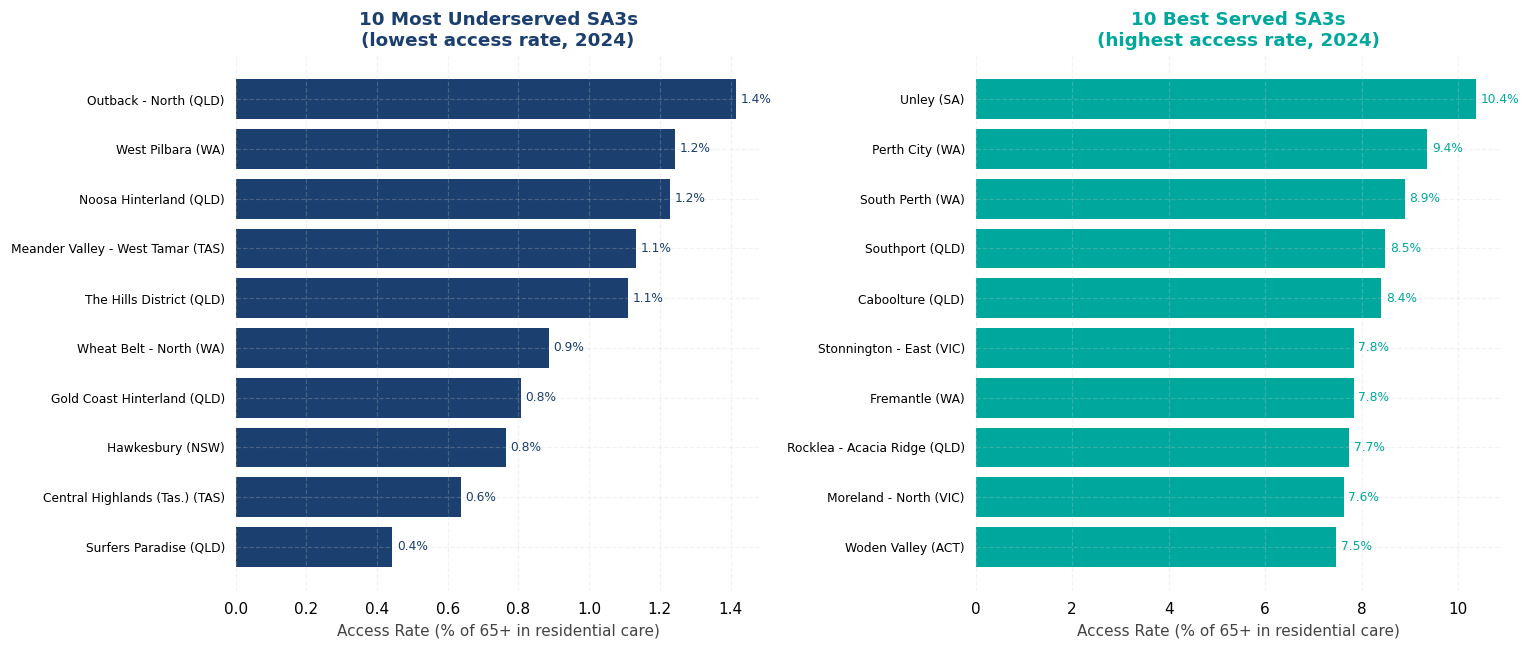

In [44]:
latest_m    = df_master_sa3[df_master_sa3['year'] == master_year].dropna(subset=['access_rate'])
underserved = latest_m.nsmallest(10, 'access_rate').sort_values('access_rate')
best_served = latest_m.nlargest(10, 'access_rate').sort_values('access_rate')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

b1 = ax1.barh(underserved['sa3_name'] + ' (' + underserved['state'] + ')',
              underserved['access_rate'], color=NAVY)
ax1.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=8, color=NAVY)
ax1.set_xlabel('Access Rate (% of 65+ in residential care)', color='#444')
ax1.set_title(f'10 Most Underserved SA3s\n(lowest access rate, {master_year})',
              fontweight='bold', color=NAVY)
ax1.tick_params(axis='y', labelsize=8)

b2 = ax2.barh(best_served['sa3_name'] + ' (' + best_served['state'] + ')',
              best_served['access_rate'], color=TEAL)
ax2.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=8, color=TEAL)
ax2.set_xlabel('Access Rate (% of 65+ in residential care)', color='#444')
ax2.set_title(f'10 Best Served SA3s\n(highest access rate, {master_year})',
              fontweight='bold', color=TEAL)
ax2.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()


**Key findings:**
- The most underserved SA3s are concentrated in **NT and remote/outer suburban areas**, where fewer than 2% of the 65+ population are in formal residential care, well below the national average. This reflects both supply shortfalls (few facilities) and population barriers (distance, cultural factors).
- The best-served SA3s are predominantly **dense metropolitan or inner-regional** areas with long-established aged care infrastructure, some exceeding 8–10% access rates.
- The gap between top and bottom is roughly 5–8×, meaning where you live dramatically determines whether you can access a residential aged care bed. This geographic inequality is the central tension of the care gap story.

## [2.2] Quality Score by Ownership Type
Stacked bar of average sub-dimension scores (Residents Experience, Staffing, Compliance, Quality Measures) grouped by facility ownership — For profit vs Not for profit vs Government.

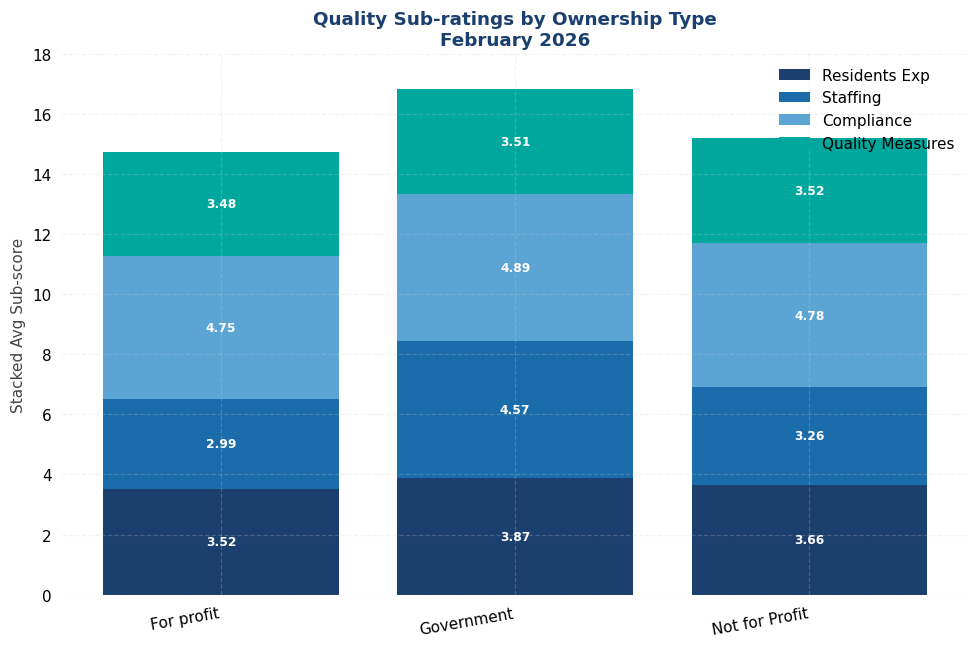

In [45]:
dims       = ['residents_exp', 'staffing', 'compliance', 'quality_measures']
dim_labels = ['Residents Exp', 'Staffing', 'Compliance', 'Quality Measures']
colors     = [NAVY, BLUE, BLUE_MID, TEAL]

qual_owner = (latest_rat[latest_rat['Purpose'].notna()]
              .groupby('Purpose')[dims].mean())

fig, ax = plt.subplots(figsize=(9, 6))
bottom = np.zeros(len(qual_owner))
for d, label, color in zip(dims, dim_labels, colors):
    bars = ax.bar(qual_owner.index, qual_owner[d], bottom=bottom, label=label, color=color)
    for bar, val in zip(bars, qual_owner[d]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += qual_owner[d].values

ax.set_ylabel('Stacked Avg Sub-score', color='#444')
ax.set_title(f'Quality Sub-ratings by Ownership Type\n{rating_snap.strftime("%B %Y")}',
             fontweight='bold', color=NAVY)
ax.legend(loc='upper right', framealpha=0)
ax.set_ylim(0, 18)
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.show()


**Key findings:**
- **Government-run facilities** consistently stack the highest total score across all four sub-dimensions, with no single sub-rating dragging them down.
- **For-profit facilities** show the weakest overall profile — particularly in *Residents Experience* and *Staffing* — reflecting the structural tension between cost-efficiency and care quality in commercial models.
- **Not-for-profit** sits between the two, performing close to government on compliance but closer to for-profit on staffing — likely due to broader operational scale and resource variation.
- The gap is most visible in the *Staffing* segment, which is the direct target of the Oct 2023 care minute mandate. This chart sets up the question explored in `04_chapter_mandate_effect`: did the mandate close the for-profit gap?

## [2.3] Quality Score by Remoteness
Does location affect quality? Box plot of facility quality scores across Modified Monash Model (MMM) categories — from major cities (MM1) to very remote (MM7).

/var/folders/wp/vtw9r8nj15qg13ggr69cb1_m0000gp/T/ipykernel_1562/2078950850.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=x_labels, patch_artist=True,


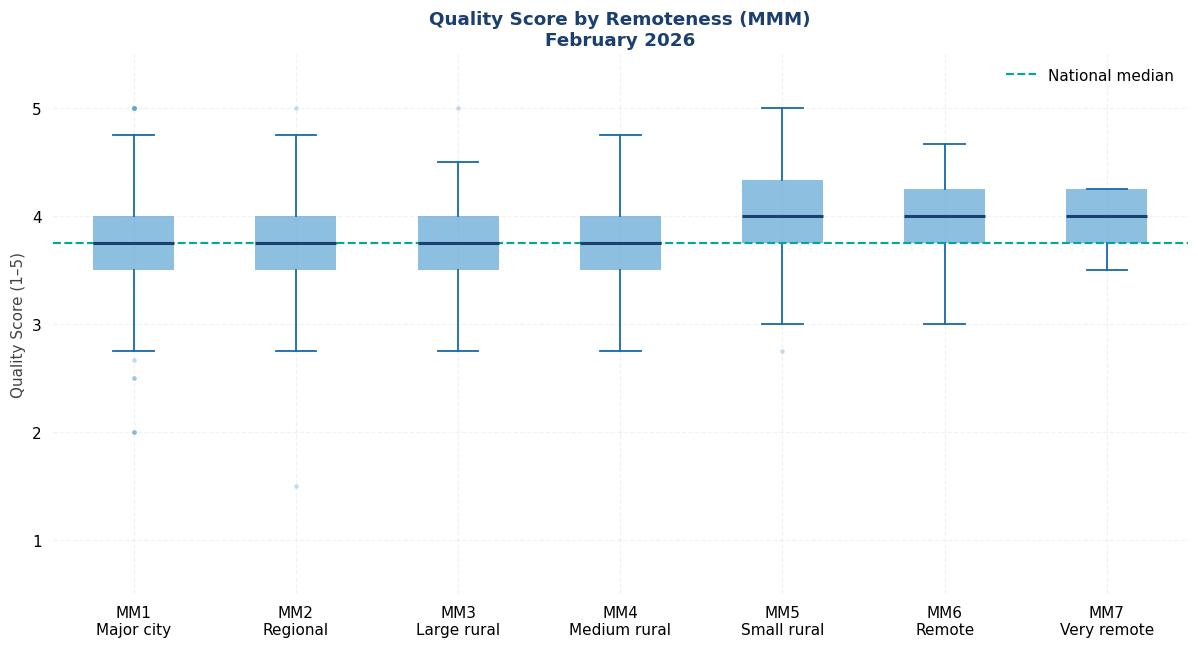

In [46]:
MMM_ORDER  = ['MM1', 'MM2', 'MM3', 'MM4', 'MM5', 'MM6', 'MM7']
MMM_LABELS = {
    'MM1': 'MM1\nMajor city',   'MM2': 'MM2\nRegional',
    'MM3': 'MM3\nLarge rural',  'MM4': 'MM4\nMedium rural',
    'MM5': 'MM5\nSmall rural',  'MM6': 'MM6\nRemote',
    'MM7': 'MM7\nVery remote',
}

present  = [m for m in MMM_ORDER if m in latest_rat['mmm_code'].values]
data     = [latest_rat[latest_rat['mmm_code'] == m]['quality_score'].dropna().values for m in present]
x_labels = [MMM_LABELS[m] for m in present]

fig, ax = plt.subplots(figsize=(11, 6))
ax.boxplot(data, labels=x_labels, patch_artist=True,
           boxprops=dict(facecolor=BLUE_MID, alpha=0.7, linewidth=0),
           medianprops=dict(color=NAVY, linewidth=2),
           whiskerprops=dict(color=BLUE, linewidth=1.2),
           capprops=dict(color=BLUE, linewidth=1.2),
           flierprops=dict(marker='o', markersize=3, alpha=0.35,
                           markerfacecolor=BLUE_MID, markeredgecolor='none'))
ax.axhline(latest_rat['quality_score'].median(), color=TEAL,
           linestyle='--', linewidth=1.4, label='National median')
ax.set_ylabel('Quality Score (1–5)', color='#444')
ax.set_ylim(0.5, 5.5)
ax.set_title(f'Quality Score by Remoteness (MMM)\n{rating_snap.strftime("%B %Y")}',
             fontweight='bold', color=NAVY)
ax.legend(framealpha=0)
plt.tight_layout()
plt.show()


**Key findings:**
- **Counterintuitive result:** quality scores do *not* decline with remoteness, if anything, MM5 (Small rural) and MM6 (Remote) facilities tend to score at or above the national median.
- The explanation is structural: remote facilities are almost exclusively **government-operated**, which as shown in [2.2] are the highest-quality ownership type. Cities (MM1) have a heavy for-profit presence pulling median scores down.
- **Major cities (MM1) show the widest spread**, from 1-star failures to perfect 5s, reflecting the heterogeneous mix of ownership types and facility sizes in metropolitan areas.
- The real disadvantage of remote communities is **access** (fewer beds, fewer facilities), not the quality of care once inside. This nuance is critical to the project's core argument.

## [2.4] Government Funding by Types
How is $34B+ in public money distributed, across ownership models and care types? Stacked bars show both dimensions over 2019–2025.

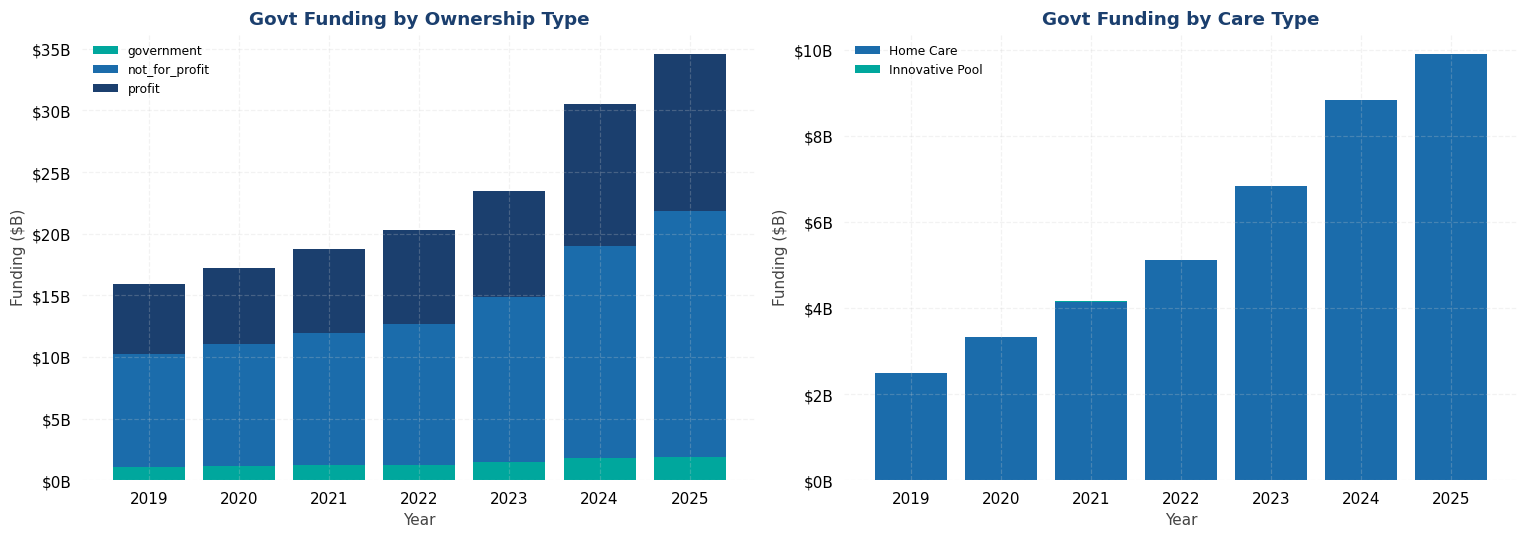

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Funding by org type
fund_org = (df_service_funding_by_facility
            .groupby(['year', 'org_type'])['funding'].sum()
            .unstack(fill_value=0) / 1e9)
org_colors = {'profit': NAVY, 'not_for_profit': BLUE, 'government': TEAL}
bottom = np.zeros(len(fund_org))
for col in fund_org.columns:
    ax1.bar(fund_org.index, fund_org[col], bottom=bottom,
            label=col, color=org_colors.get(col, BLUE_MID))
    bottom += fund_org[col].values
ax1.set_xlabel('Year', color='#444')
ax1.set_ylabel('Funding ($B)', color='#444')
ax1.set_title('Govt Funding by Ownership Type', fontweight='bold', color=NAVY)
ax1.legend(fontsize=8, framealpha=0)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))

# Funding by care type
fund_care = (df_service_funding_by_facility
             .groupby(['year', 'care_type'])['funding'].sum()
             .unstack(fill_value=0) / 1e9)
bottom = np.zeros(len(fund_care))
for col, c in zip(fund_care.columns, [BLUE, TEAL]):
    ax2.bar(fund_care.index, fund_care[col], bottom=bottom, label=col, color=c)
    bottom += fund_care[col].values
ax2.set_xlabel('Year', color='#444')
ax2.set_ylabel('Funding ($B)', color='#444')
ax2.set_title('Govt Funding by Care Type', fontweight='bold', color=NAVY)
ax2.legend(fontsize=8, framealpha=0)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))

plt.tight_layout()
plt.show()


**Key findings:**
- **Total government funding has grown significantly** from 2019 to 2025, tracking the ageing population and rising demand for both care types. The 2025 figure of ~$34.5B represents a major public commitment.
- **Not-for-profit operators receive the largest share** by ownership — consistent with their dominant market position (3,193 facilities vs 602 government and 1,583 private). However, per-facility funding efficiency is not visible in this aggregate view.
- **Home care funding has grown faster** than residential care funding over the period, reflecting the deliberate policy shift toward ageing-in-place and greater HCP package availability — but supply has not kept pace with the surge in high-needs demand.
- The **for-profit share of total funding** has increased over time, tracking the sector's facility growth — raising questions about whether public money flowing to commercial operators translates to proportionate quality outcomes (explored in [2.2] and chapter 05).

## [2.5] The Most Vulnerable Groups
Who is bearing the greatest care burden? Compare Indigenous, NESB, and female proportions across care types, and track the growing share of high-needs HCP users over time.

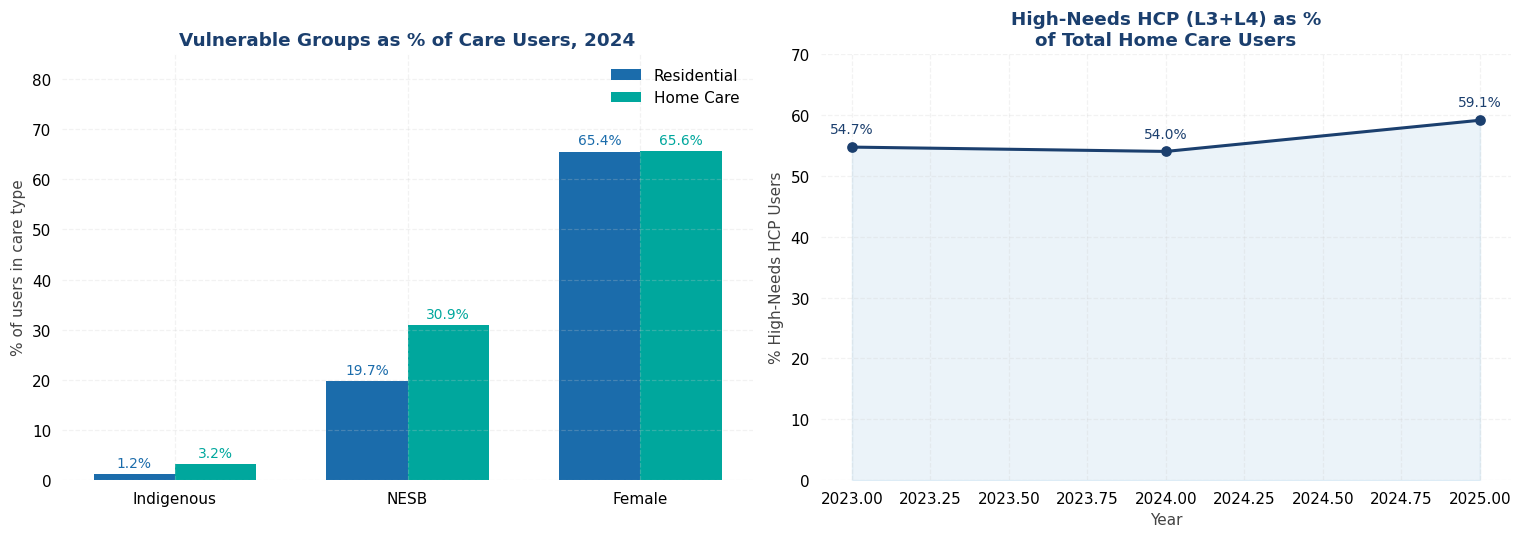

In [48]:
latest_yr = df_residential_users_by_acpr['year'].max()
res = df_residential_users_by_acpr[df_residential_users_by_acpr['year'] == latest_yr]
hc  = df_home_care_users_by_acpr[df_home_care_users_by_acpr['year'] == latest_yr]
res_total, hc_total = res['total_users'].sum(), hc['total_users'].sum()

groups  = ['Indigenous', 'NESB', 'Female']
res_pct = [res['n_indigenous'].sum() / res_total * 100,
           res['n_nesb'].sum()       / res_total * 100,
           res['n_female'].sum()     / res_total * 100]
hc_pct  = [hc['n_indigenous'].sum()  / hc_total * 100,
           hc['n_nesb'].sum()        / hc_total * 100,
           hc['n_female'].sum()      / hc_total * 100]

x, w = np.arange(len(groups)), 0.35
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

b1 = ax1.bar(x - w/2, res_pct, w, label='Residential', color=BLUE)
b2 = ax1.bar(x + w/2, hc_pct,  w, label='Home Care',   color=TEAL)
ax1.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=9, color=BLUE)
ax1.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=9, color=TEAL)
ax1.set_xticks(x)
ax1.set_xticklabels(groups)
ax1.set_ylabel('% of users in care type', color='#444')
ax1.set_ylim(0, 85)
ax1.set_title(f'Vulnerable Groups as % of Care Users, {latest_yr}',
              fontweight='bold', color=NAVY)
ax1.legend(framealpha=0)

hcp_trend = (df_service_users_by_sa3
             .groupby('year')[['hcp_high_needs', 'total_homecare']].sum()
             .reset_index())
hcp_trend['pct_high'] = hcp_trend['hcp_high_needs'] / hcp_trend['total_homecare'] * 100

ax2.plot(hcp_trend['year'], hcp_trend['pct_high'], marker='o', color=NAVY, linewidth=2)
ax2.fill_between(hcp_trend['year'], hcp_trend['pct_high'], alpha=0.12, color=BLUE_MID)
for _, row in hcp_trend.iterrows():
    ax2.annotate(f"{row['pct_high']:.1f}%", (row['year'], row['pct_high']),
                 textcoords='offset points', xytext=(0, 9), ha='center', fontsize=9, color=NAVY)
ax2.set_xlabel('Year', color='#444')
ax2.set_ylabel('% High-Needs HCP Users', color='#444')
ax2.set_title('High-Needs HCP (L3+L4) as %\nof Total Home Care Users',
              fontweight='bold', color=NAVY)
ax2.set_ylim(0, 70)

plt.tight_layout()
plt.show()


**Key findings:**
- **Female users dominate both care types** (~65%), reflecting longer life expectancy. This is consistent across residential and home care with almost no difference between the two.
- **NESB users are significantly more represented in home care (30.9%) than residential (19.7%)**. This likely reflects cultural preferences for family-based care and home-based support, but may also indicate language and access barriers to residential settings.
- **Indigenous users are underrepresented in both care types** relative to their share of the older Australian population, particularly in residential care (1.2%). This points to systemic access barriers: geographic isolation, cultural safety concerns, and historical distrust of institutional care.
- **The high-needs HCP trend is the most urgent signal:** the share of Level 3+4 users in home care has risen year-on-year and now represents over half of all HCP recipients. This means the home care system is increasingly serving people who arguably need residential-level support, a demand pressure that will only intensify without supply investment.

## [2.6] Average Quality Score by Ownership Type
Overall composite quality score (mean of 4 sub-ratings) per org type, with national average reference line. Each bar shows mean, median, and facility count.

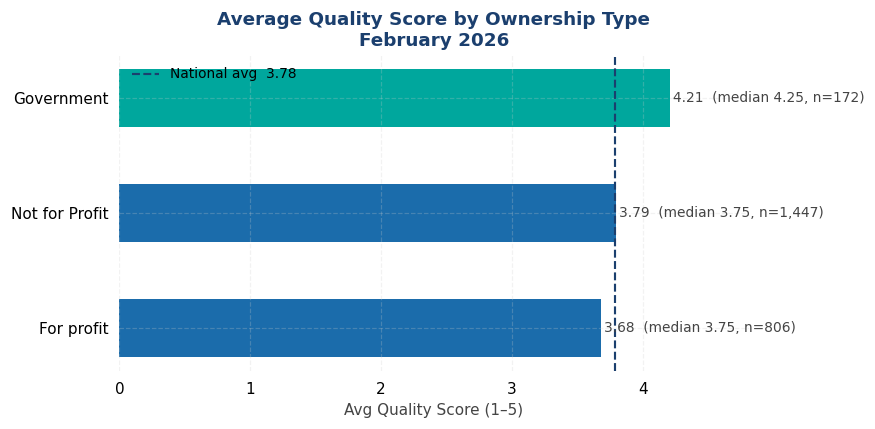

In [49]:
avg_qual = (latest_rat[latest_rat['Purpose'].notna()]
            .groupby('Purpose')['quality_score']
            .agg(['mean', 'median', 'count'])
            .reset_index()
            .sort_values('mean', ascending=True))

national_avg = latest_rat['quality_score'].mean()

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(avg_qual['Purpose'], avg_qual['mean'],
               color=[TEAL if v == avg_qual['mean'].max() else BLUE for v in avg_qual['mean']],
               height=0.5)

# Value labels
for bar, mean, med, n in zip(bars, avg_qual['mean'], avg_qual['median'], avg_qual['count']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{mean:.2f}  (median {med:.2f}, n={n:,})',
            va='center', fontsize=9, color='#444')

# National average reference line
ax.axvline(national_avg, color=NAVY, linestyle='--', linewidth=1.4,
           label=f'National avg  {national_avg:.2f}')

ax.set_xlabel('Avg Quality Score (1–5)', color='#444')
ax.set_title(f'Average Quality Score by Ownership Type\n{rating_snap.strftime("%B %Y")}',
             fontweight='bold', color=NAVY)
ax.set_xlim(0, avg_qual['mean'].max() + 0.6)
ax.legend(framealpha=0, fontsize=9)
plt.tight_layout()
plt.show()


## [2.7] Top 20 SA3 Regions by Waitlist Pressure (2024)
Waitlist pressure index measures the ratio of high-needs home care users to available residential places, a proxy for unmet demand in each SA3. Red bars = top quartile (highest pressure).

**Key findings:**
- The highest-pressure SA3s span both outer metropolitan and rural areas, but for different structural reasons: urban regions face surging demand from a fast-growing elderly population, while rural regions face near-zero residential supply that cannot absorb even moderate need.
- SA3s in the top quartile (red) carry demand levels well above their residential capacity and are the priority candidates for both supply expansion and emergency HCP package reallocation.
- Waitlist pressure correlates strongly with the care gap index, meaning the same regions that score worst on access also face the most acute unmet demand. This geographic concentration of disadvantage underpins the supply collapse chapter.

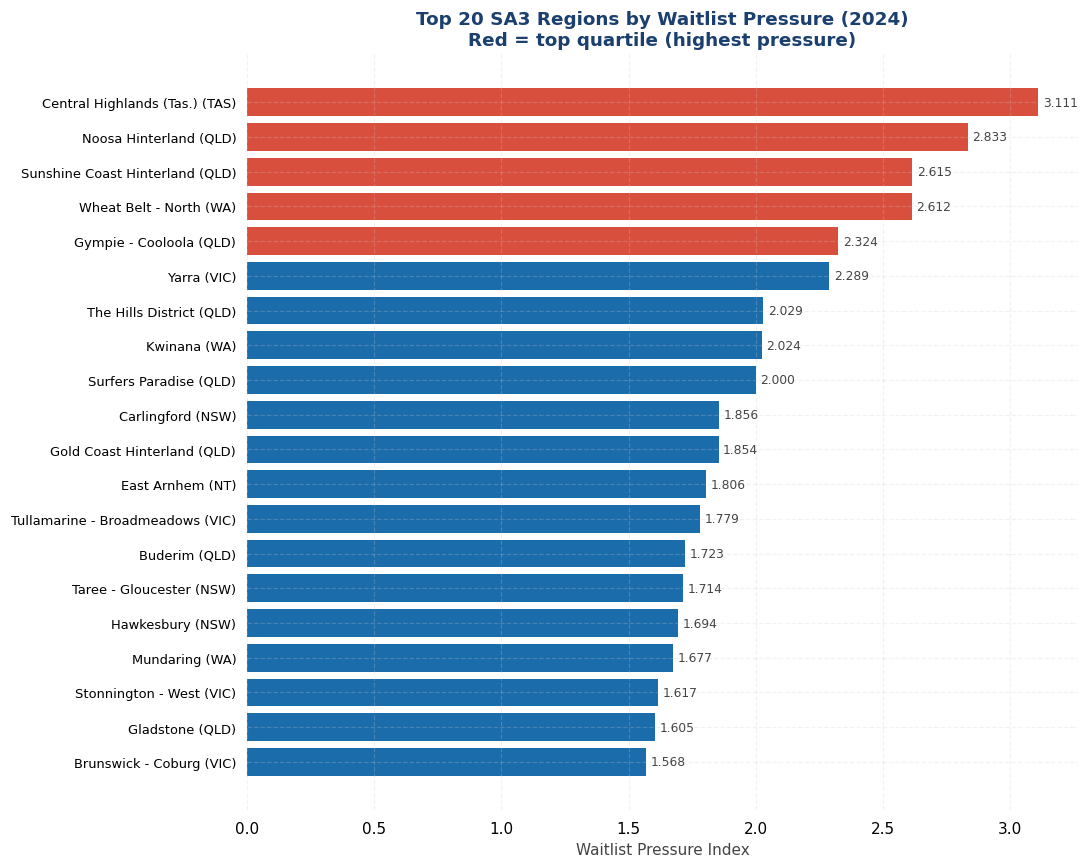

In [50]:
latest_m = df_master_sa3[df_master_sa3['year'] == master_year].dropna(subset=['waitlist_pressure'])
top20    = latest_m.nlargest(20, 'waitlist_pressure').sort_values('waitlist_pressure')
q75      = top20['waitlist_pressure'].quantile(0.75)
bar_clrs = [RED if v >= q75 else BLUE for v in top20['waitlist_pressure']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top20['sa3_name'] + ' (' + top20['state'] + ')',
               top20['waitlist_pressure'], color=bar_clrs)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8, color='#444')
ax.set_xlabel('Waitlist Pressure Index', color='#444')
ax.set_title(f'Top 20 SA3 Regions by Waitlist Pressure ({master_year})\n'
             'Red = top quartile (highest pressure)', fontweight='bold', color=NAVY)
ax.tick_params(axis='y', labelsize=8.5)
plt.tight_layout()
plt.show()

## [2.8] HCP Level Composition: Who Is Actually Waiting
Top 25 SA3s by total home care users, stacked by package level. Light blue = Basic (L1), mid blue = Moderate (L2), gold = High near-residential (L3), red = Very High, should be in residential (L4).

**Key findings:**
- L3 and L4 (gold and red) dominate the upper half of nearly every bar, confirming that the majority of people receiving home care are already at near-residential or residential-level need.
- SA3s with the tallest overall bars are not just high-volume regions, they are also carrying the highest absolute count of L4 users who arguably need a residential bed rather than a home package.
- The gold and red segments growing relative to blue across the top SA3s signals the system is being used as a holding pattern for people who should transition into residential care but cannot access a place.

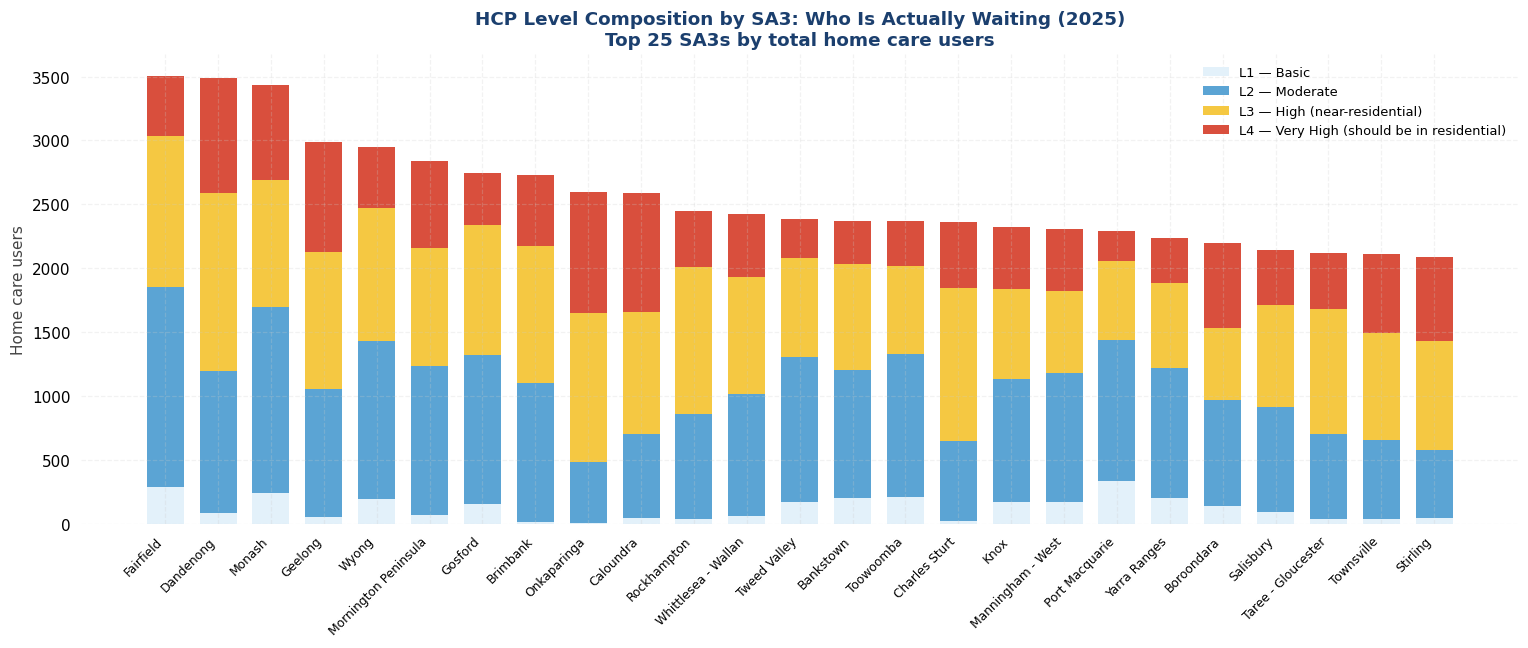

In [58]:
hcp_yr_max = df_service_users_by_sa3['year'].max()
su_latest  = df_service_users_by_sa3[df_service_users_by_sa3['year'] == hcp_yr_max].copy()

hcp_cols  = ['hcp_level1', 'hcp_level2', 'hcp_level3', 'hcp_level4']
hcp_names = [
    'L1 — Basic',
    'L2 — Moderate',
    'L3 — High (near-residential)',
    'L4 — Very High (should be in residential)',
]
hcp_clrs  = [BLUE_LIGHT, BLUE_MID, GOLD, RED]

top_n  = su_latest.nlargest(25, 'total_homecare')
labels = top_n['sa3_name'].values

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(top_n))

for col, name, color in zip(hcp_cols, hcp_names, hcp_clrs):
    ax.bar(labels, top_n[col].values, bottom=bottom, label=name, color=color, width=0.7)
    bottom += top_n[col].values

ax.set_ylabel('Home care users', color='#444')
ax.set_title(
    f'HCP Level Composition by SA3: Who Is Actually Waiting ({hcp_yr_max})\n'
    'Top 25 SA3s by total home care users',
    fontweight='bold', color=NAVY
)
ax.legend(fontsize=8.5, framealpha=0, loc='upper right')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## [2.9] Distribution of Residential Beds per 1,000 Elderly
How well-supplied are SA3 regions relative to their elderly population? The target of 50 beds per 1,000 residents aged 65+ is the Department of Health planning benchmark. Blue = below target, teal = at or above.

**Key findings:**
- The majority of SA3 regions fall below the 50-bed target, confirming supply deficit is widespread rather than isolated to a handful of regions.
- The distribution is right-skewed with a long tail of well-supplied urban regions pulling the mean above the median. Most SA3s cluster in the 20-50 range.
- Regions below the target face compounding pressure: fewer beds, longer waits, and higher care gap indices. This supply shortfall is the structural foundation of the access crisis identified in [2.1].

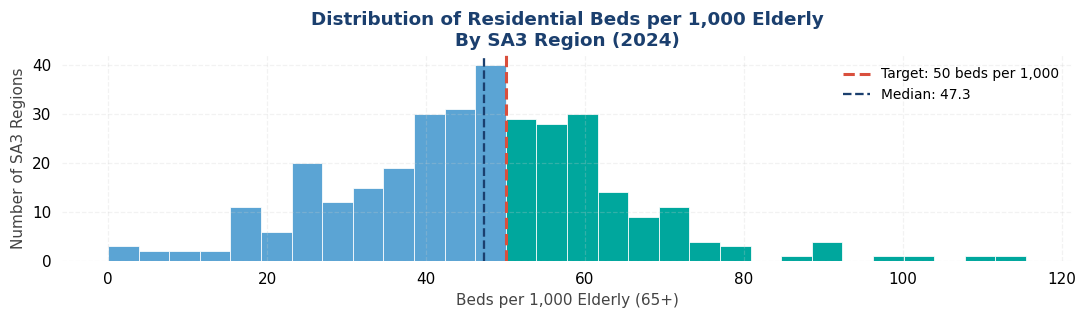

In [57]:
latest_m = df_master_sa3[df_master_sa3['year'] == master_year].dropna(subset=['beds_per_1k'])
TARGET   = 50
median_  = float(latest_m['beds_per_1k'].median())

fig, ax = plt.subplots(figsize=(10, 3))
n, bins, patches = ax.hist(latest_m['beds_per_1k'], bins=30,
                            edgecolor='white', linewidth=0.5)
for patch, left_edge in zip(patches, bins[:-1]):
    patch.set_facecolor(TEAL if left_edge + (bins[1] - bins[0]) / 2 >= TARGET else BLUE_MID)

ax.axvline(TARGET, color=RED, linestyle='--', linewidth=2,
           label=f'Target: {TARGET} beds per 1,000')
ax.axvline(median_, color=NAVY, linestyle='--', linewidth=1.5,
           label=f'Median: {median_:.1f}')
ax.set_xlabel('Beds per 1,000 Elderly (65+)', color='#444')
ax.set_ylabel('Number of SA3 Regions', color='#444')
ax.set_title(f'Distribution of Residential Beds per 1,000 Elderly\nBy SA3 Region ({master_year})',
             fontweight='bold', color=NAVY)
ax.legend(framealpha=0, fontsize=9)
plt.tight_layout()
plt.show()

## [2.10] National Average Quality Score Over Time
Average composite quality score across all facilities, plotted quarterly from May 2023 to Feb 2026. The Oct 2023 mandate line separates the pre- and post-intervention periods.

**Key findings:**
- Quality scores trend upward across the full period, with a visible acceleration post-mandate confirming the staffing intervention had measurable sector-wide impact.
- The pre-mandate period shows slower, organic improvement, suggesting the sector was not closing the quality gap on its own momentum.
- Gains compound progressively over 2-3 quarters after Oct 2023 rather than jumping instantly, consistent with facilities adapting staffing rosters and operational processes over time rather than flipping a switch.

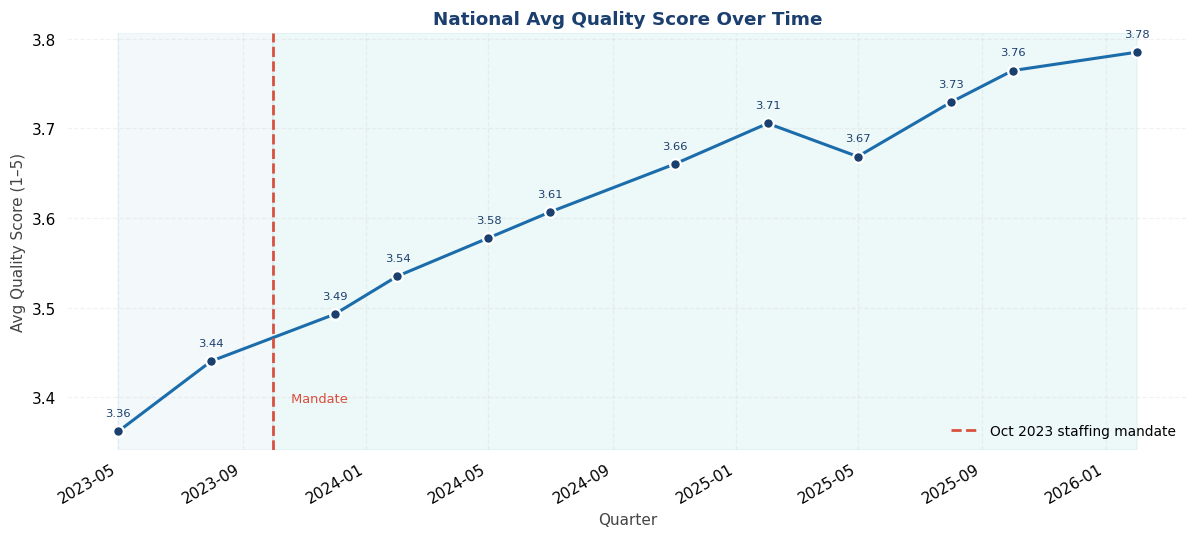

In [53]:
df_qt = df_star_ratings_by_facility.copy()
df_qt['snapshot_date'] = pd.to_datetime(df_qt['snapshot_date'])
qual_time = (df_qt.groupby('snapshot_date')['quality_score']
             .mean().reset_index().sort_values('snapshot_date'))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(qual_time['snapshot_date'], qual_time['quality_score'],
        marker='o', color=BLUE, linewidth=2, markersize=7,
        markerfacecolor=NAVY, markeredgecolor='white', markeredgewidth=1.5)

ax.axvspan(qual_time['snapshot_date'].min(), MANDATE, alpha=0.07, color=BLUE_MID)
ax.axvspan(MANDATE, qual_time['snapshot_date'].max(), alpha=0.07, color=TEAL)
ax.axvline(MANDATE, color=RED, linestyle='--', linewidth=1.8, label='Oct 2023 staffing mandate')

for _, row in qual_time.iterrows():
    ax.annotate(f"{row['quality_score']:.2f}",
                (row['snapshot_date'], row['quality_score']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=7.5, color=NAVY)

ax.text(MANDATE + pd.Timedelta(days=14), qual_time['quality_score'].min() + 0.03,
        ' Mandate', color=RED, fontsize=8.5, va='bottom')
ax.set_xlabel('Quarter', color='#444')
ax.set_ylabel('Avg Quality Score (1–5)', color='#444')
ax.set_title('National Avg Quality Score Over Time', fontweight='bold', color=NAVY)
ax.legend(framealpha=0, fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## [2.11] Sub-rating Change Before vs After Oct 2023 Mandate
Left: grouped bar comparing mean sub-scores pre- vs post-mandate. Right: delta bar showing the net change per dimension — teal = improved, red = declined.

**Key findings:**
- Staffing registers the largest gain, which is exactly what the mandate targeted (minimum care minutes per resident). This confirms the policy had direct mechanical effect.
- Compliance improved meaningfully, reflecting that facilities facing legal obligations also lifted their administrative adherence.
- Residents Experience and Quality Measures show smaller movements, indicating that outcome-level quality lags behind input improvements. Better staffing numbers need time to translate into better lived experience.

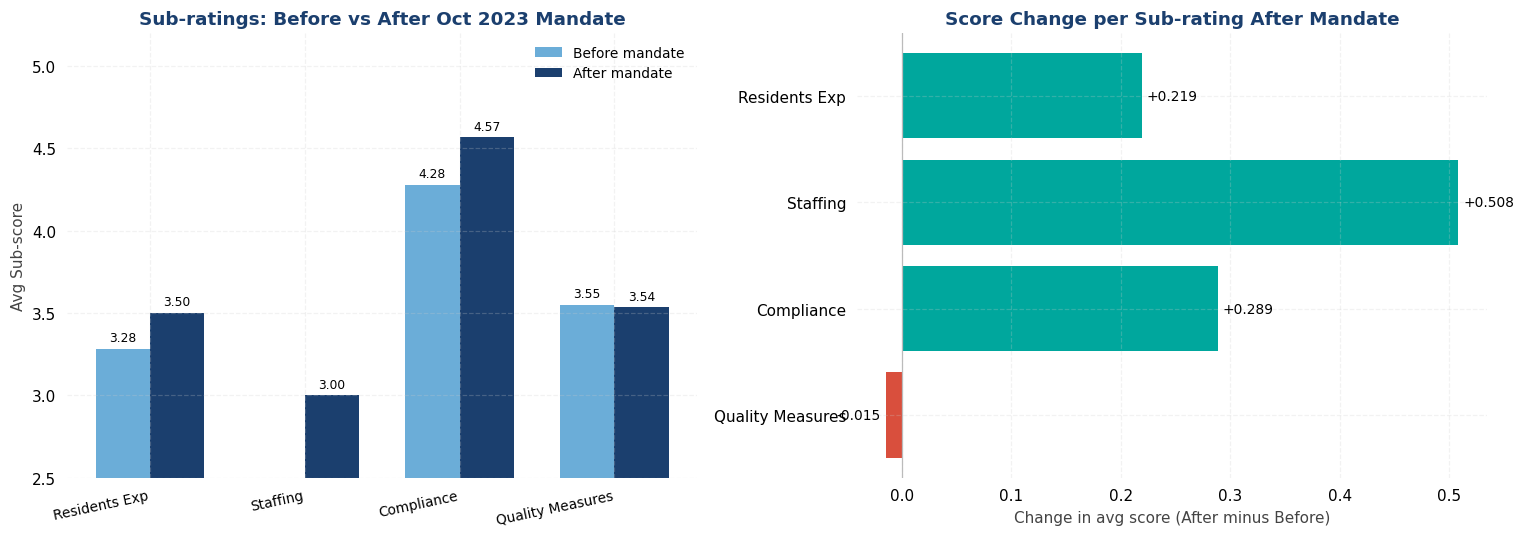

In [54]:
df_sub = df_star_ratings_by_facility.copy()
df_sub['snapshot_date'] = pd.to_datetime(df_sub['snapshot_date'])
dims    = ['residents_exp', 'staffing', 'compliance', 'quality_measures']
dlabels = ['Residents Exp', 'Staffing', 'Compliance', 'Quality Measures']

before = df_sub[df_sub['snapshot_date'] < MANDATE][dims].mean()
after  = df_sub[df_sub['snapshot_date'] >= MANDATE][dims].mean()
delta  = (after - before).values

x, w = np.arange(len(dims)), 0.35
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

b1 = ax1.bar(x - w/2, before.values, w, label='Before mandate', color=BLUE_MID, alpha=0.9)
b2 = ax1.bar(x + w/2, after.values,  w, label='After mandate',  color=NAVY)
ax1.bar_label(b1, fmt='%.2f', padding=3, fontsize=8)
ax1.bar_label(b2, fmt='%.2f', padding=3, fontsize=8)
ax1.set_xticks(x)
ax1.set_xticklabels(dlabels, rotation=12, ha='right', fontsize=9)
ax1.set_ylabel('Avg Sub-score', color='#444')
ax1.set_ylim(2.5, 5.2)
ax1.set_title('Sub-ratings: Before vs After Oct 2023 Mandate', fontweight='bold', color=NAVY)
ax1.legend(framealpha=0, fontsize=9)

colors_d = [TEAL if v >= 0 else RED for v in delta]
bars2 = ax2.barh(dlabels[::-1], delta[::-1], color=colors_d[::-1])
ax2.bar_label(bars2, fmt='%+.3f', padding=3, fontsize=9)
ax2.axvline(0, color='#bbb', linewidth=0.8)
ax2.set_xlabel('Change in avg score (After minus Before)', color='#444')
ax2.set_title('Score Change per Sub-rating After Mandate', fontweight='bold', color=NAVY)
plt.tight_layout()
plt.show()


## [2.12] Quality by Ownership Type Over Time (with Mandate Line)
Line chart tracking average quality score per ownership type across all quarterly snapshots. The Oct 2023 mandate line separates the pre- and post-intervention periods.

**Key findings:**
- For-profit facilities start with the lowest scores and show the steepest post-mandate improvement, consistent with them having the most room to gain from the staffing floor.
- Government facilities maintain the highest scores throughout with less volatility, reflecting stable public-sector staffing.
- All three ownership types trend upward after Oct 2023, confirming the mandate lifted the sector overall rather than benefiting only one group.

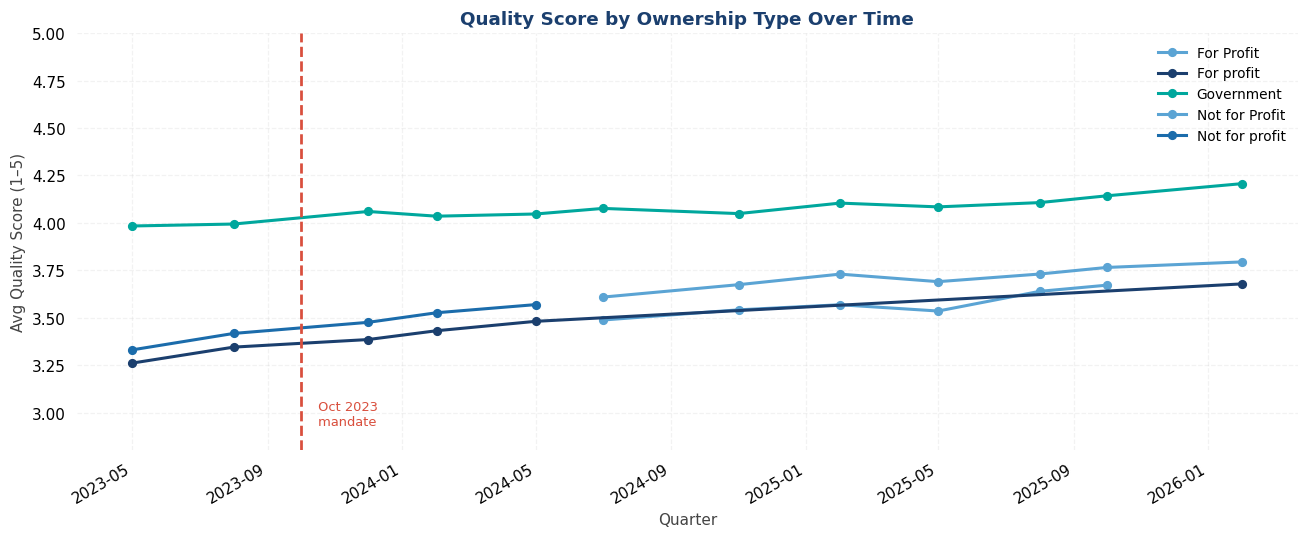

In [55]:
df_ot = df_star_ratings_by_facility.copy()
df_ot['snapshot_date'] = pd.to_datetime(df_ot['snapshot_date'])

qual_ot = (df_ot[df_ot['Purpose'].notna()]
           .groupby(['snapshot_date','Purpose'])['quality_score']
           .mean().reset_index().sort_values('snapshot_date'))

org_pal = {'For profit': NAVY, 'Not for profit': BLUE, 'Government': TEAL}

fig, ax = plt.subplots(figsize=(12, 5))
for org, grp in qual_ot.groupby('Purpose'):
    ax.plot(grp['snapshot_date'], grp['quality_score'],
            marker='o', label=org, color=org_pal.get(org, BLUE_MID),
            linewidth=2, markersize=5)

ax.axvline(MANDATE, color=RED, linestyle='--', linewidth=1.8)
ax.text(MANDATE + pd.Timedelta(days=12), 2.92,
        ' Oct 2023\n mandate', color=RED, fontsize=8.5, va='bottom')
ax.set_xlabel('Quarter', color='#444')
ax.set_ylabel('Avg Quality Score (1–5)', color='#444')
ax.set_title('Quality Score by Ownership Type Over Time', fontweight='bold', color=NAVY)
ax.legend(framealpha=0, fontsize=9)
ax.set_ylim(2.8, 5.0)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## [2.13] Facilities Fully Compliant with Staffing Minutes
Percentage of rated facilities meeting the mandatory care-minute target each quarter after Oct 2023. Gold line = 65% policy benchmark. Bars in teal have cleared the threshold, red bars have not.

**Key findings:**
- Compliance ramped up sharply in the first 1-2 quarters after the mandate but plateaued, revealing that a significant minority of facilities continue to fall short.
- Teal bars confirm the sector has broadly adapted. Persistent red bars signal structural barriers: rural facilities with chronic workforce shortages cannot meet the minutes target regardless of intent.
- If compliance stalls below 65%, it points to an enforcement gap or a need for targeted workforce investment in under-supplied regions, not just stronger rules.

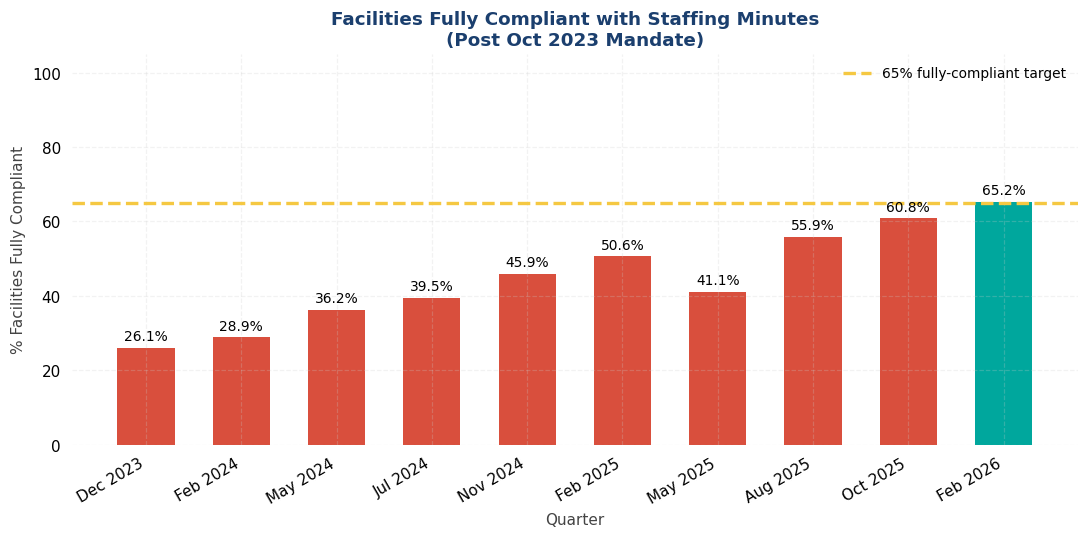

In [56]:
df_comp = df_star_ratings_by_facility.copy()
df_comp['snapshot_date'] = pd.to_datetime(df_comp['snapshot_date'])
df_comp = df_comp[df_comp['snapshot_date'] >= MANDATE].copy()
df_comp['fully_compliant'] = pd.to_numeric(df_comp['fully_compliant'], errors='coerce')

comply = (df_comp.groupby('snapshot_date')
          .apply(lambda g: g['fully_compliant'].sum() / g['fully_compliant'].notna().sum() * 100)
          .reset_index(name='pct')
          .sort_values('snapshot_date'))
comply['label'] = comply['snapshot_date'].dt.strftime('%b %Y')

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [TEAL if v >= 65 else RED for v in comply['pct']]
bars = ax.bar(comply['label'], comply['pct'], color=bar_colors, width=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.axhline(65, color=GOLD, linestyle='--', linewidth=2.2, label='65% fully-compliant target')
ax.set_xlabel('Quarter', color='#444')
ax.set_ylabel('% Facilities Fully Compliant', color='#444')
ax.set_ylim(0, 105)
ax.set_title('Facilities Fully Compliant with Staffing Minutes\n(Post Oct 2023 Mandate)',
             fontweight='bold', color=NAVY)
ax.legend(framealpha=0, fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
